In [1]:
input_csv = 'DATAMwEDR_UofU 650-05-211 BHA 23 - output data.csv'

In [2]:
# Parameters
input_csv = "BHA 35r1 650-05-551 - output data.csv"


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv(input_csv, skiprows=35)

# Robust column detection
import os
import matplotlib.pyplot as plt

def find_col(data, suffix):
    for col in data.columns:
        if suffix in col:
            return col
    return None

torsionalCol = find_col(data, 'ShYpeak(g)') or "Bit Box_ShYpeak(g)"
lateralCol = find_col(data, 'ShZpeak(g)') or "Bit Box_ShZpeak(g)"
axialCol = find_col(data, 'ShXpeak(g)') or "Bit Box_ShXpeak(g)"

# Ensure image directory exists
if not os.path.exists('output_images'):
    os.makedirs('output_images')


In [5]:
data["Augmented RPM(RPM)"] = np.where(
    data["Surface_GC_Rotating(bool)"] == 1,
    data["Surface_Flow In(GPM)"] * 0.242 + data["Surface_Top Drive RPM(RPM)"],
    data["Surface_Flow In(GPM)"] * 0.242
)
data = data[(data["Augmented RPM(RPM)"] < 230) & (data["Augmented RPM(RPM)"] > 10)]

In [6]:
data = data[(data["Surface_Weight on Bit(klbs)"] >= 10) & (data["Surface_Weight on Bit(klbs)"] <= 100)]
data = data.dropna(subset=[torsionalCol])


dataDrilling = data[data["Surface_GC_OnBottom(bool)"] == 1]
dataNotDrilling = data[data["Surface_GC_OnBottom(bool)"] == 0]
dataNotDrilling["Surface_Weight on Bit(klbs)"] = 0
dataRotating = dataDrilling[dataDrilling["Surface_GC_Rotating(bool)"] == 1]
dataSliding = dataDrilling[dataDrilling["Surface_GC_Sliding(bool)"] == 1]

C:\Users\Isaac Xu\AppData\Local\Temp\ipykernel_776\1378756124.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataNotDrilling["Surface_Weight on Bit(klbs)"] = 0


In [7]:
dataDrilling = dataDrilling[dataDrilling["Surface_Weight on Bit(klbs)"] >= 10]
dataRotating = dataRotating[dataRotating["Surface_Weight on Bit(klbs)"] >= 10]
dataSliding = dataSliding[dataSliding["Surface_Weight on Bit(klbs)"] >= 10]

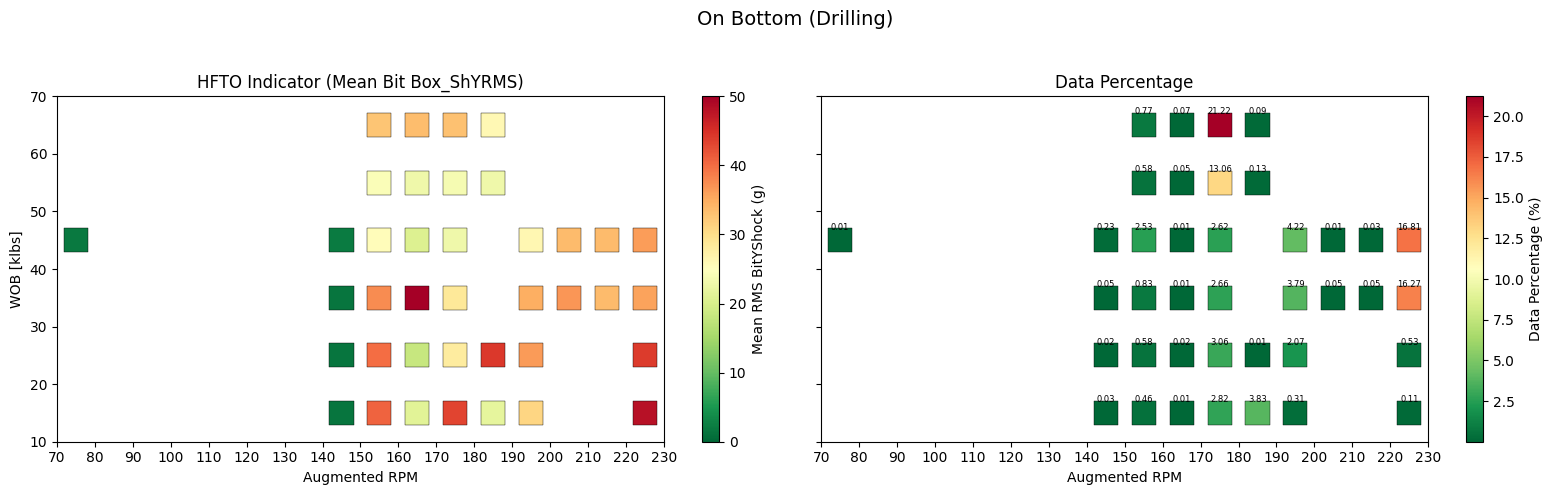

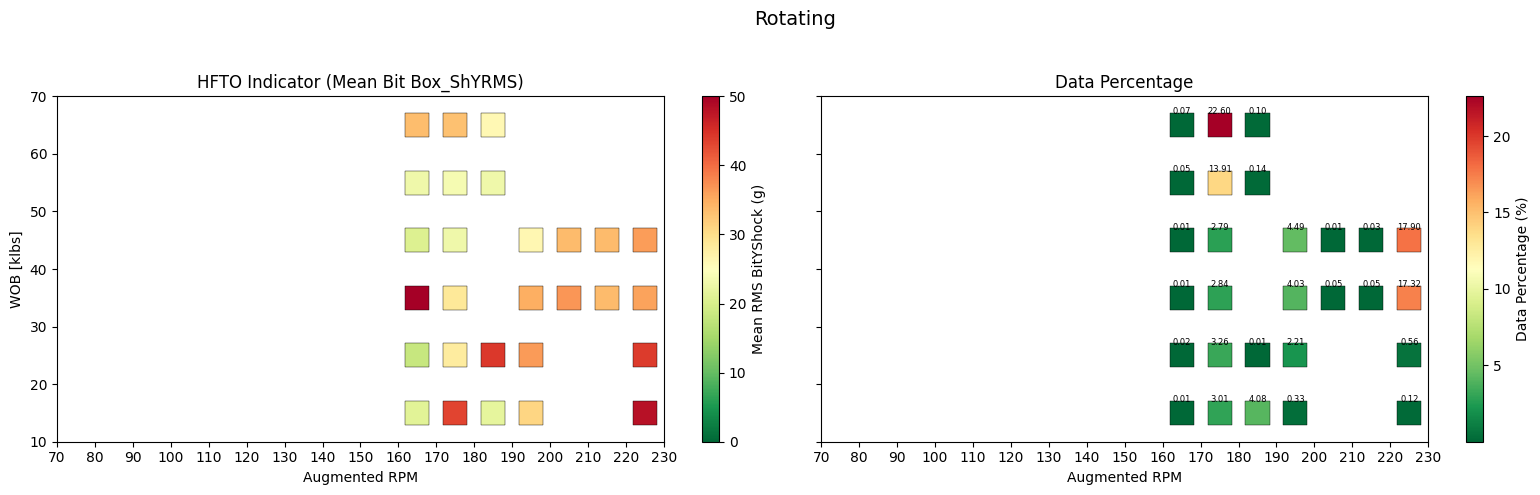

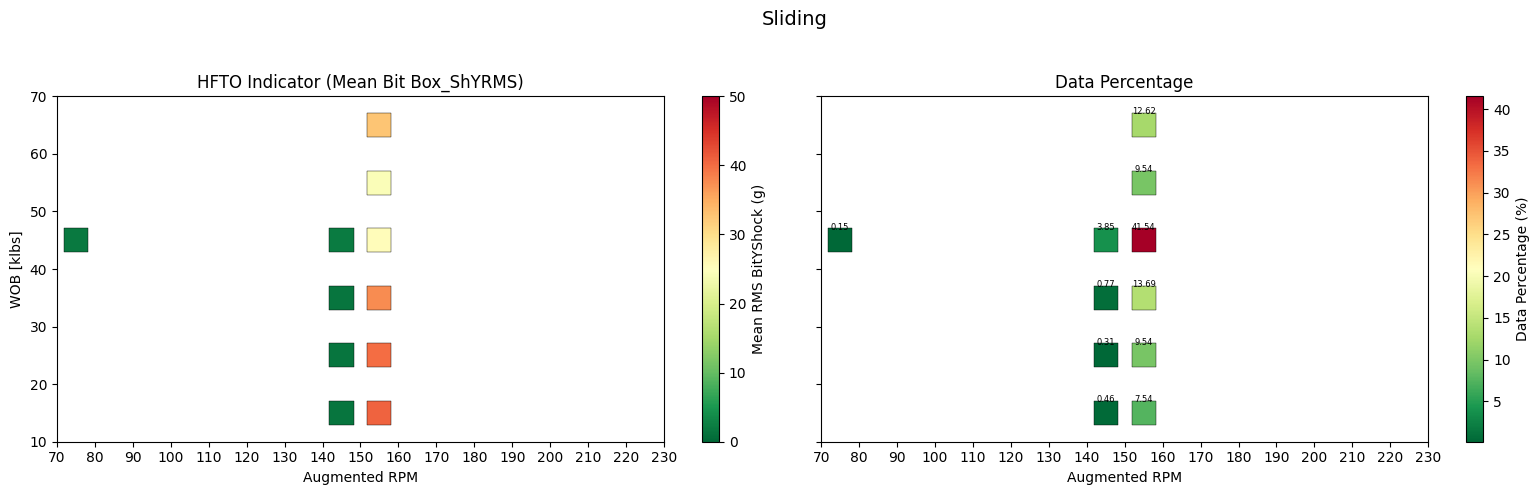

In [8]:
# ------------------------------------------------------------
# Operating states
# ------------------------------------------------------------
states = {
    "On Bottom (Drilling)": dataDrilling,
    "Rotating": dataRotating,
    "Sliding": dataSliding
}

selected_states = {
    "On Bottom (Drilling)": dataDrilling,
    "Rotating": dataRotating,
    "Sliding": dataSliding
}
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
nwob = 10
nrpm = 10

wob_col = "Surface_Weight on Bit(klbs)"
rpm_col = "Augmented RPM(RPM)"
hfto_col = torsionalCol

# ------------------------------------------------------------
# GLOBAL mins/maxes (axis starts at GLOBAL MIN, not 0)
# ------------------------------------------------------------
minrpm_raw = min(df[rpm_col].min() for df in selected_states.values())
maxrpm_raw = max(df[rpm_col].max() for df in selected_states.values())

minwob_raw = min(df[wob_col].min() for df in selected_states.values())
maxwob_raw = max(df[wob_col].max() for df in selected_states.values())

# Bin-aligned bounds
minrpm = np.floor(minrpm_raw / nrpm) * nrpm
maxrpm = np.ceil(maxrpm_raw / nrpm) * nrpm

minwob = np.floor(minwob_raw / nwob) * nwob
maxwob = np.ceil(maxwob_raw / nwob) * nwob

rpm_edges = np.arange(minrpm, maxrpm + nrpm, nrpm)
wob_edges = np.arange(minwob, maxwob + nwob, nwob)

rpm_centers = rpm_edges[:-1] + nrpm / 2
wob_centers = wob_edges[:-1] + nwob / 2
RPM, WOB = np.meshgrid(rpm_centers, wob_centers)

# ------------------------------------------------------------
# GLOBAL colorbar limits (shared across all states)
# ------------------------------------------------------------
all_hfto_vals = []
all_pct_vals = []

for df in states.values():
    n_total = len(df)

    for wob_lo, wob_hi in zip(wob_edges[:-1], wob_edges[1:]):
        for rpm_lo, rpm_hi in zip(rpm_edges[:-1], rpm_edges[1:]):
            mask = (
                (df[wob_col] >= wob_lo) & (df[wob_col] < wob_hi) &
                (df[rpm_col] >= rpm_lo) & (df[rpm_col] < rpm_hi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                all_hfto_vals.append(vals.mean())
                all_pct_vals.append((len(vals) / n_total) * 100)

hfto_vmin = 0
hfto_vmax = 50

pct_vmin = 0
pct_vmax = max(all_pct_vals) if len(all_pct_vals) else np.nan



def plot_state(df, state_name):
    hfto = np.full((len(wob_centers), len(rpm_centers)), np.nan)
    pct  = np.full_like(hfto, np.nan)

    n_total = len(df)

    for yi, (wlo, whi) in enumerate(zip(wob_edges[:-1], wob_edges[1:])):
        for xi, (rlo, rhi) in enumerate(zip(rpm_edges[:-1], rpm_edges[1:])):
            mask = (
                (df[wob_col] >= wlo) & (df[wob_col] < whi) &
                (df[rpm_col] >= rlo) & (df[rpm_col] < rhi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                hfto[yi, xi] = vals.mean()
                pct[yi, xi] = (len(vals) / n_total) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)
    fig.suptitle(state_name, fontsize=14)

    sc1 = axes[0].scatter(
        RPM.flatten(), WOB.flatten(),
        c=hfto.flatten(),
        cmap="RdYlGn_r",
        vmin=hfto_vmin, vmax=hfto_vmax,
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    sc2 = axes[1].scatter(
        RPM.flatten(), WOB.flatten(),
        c=pct.flatten(),
        cmap="RdYlGn_r",
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    axes[0].set_title("HFTO Indicator (Mean Bit Box_ShYRMS)")
    axes[1].set_title("Data Percentage")

    axes[0].set_xlabel("Augmented RPM")
    axes[0].set_ylabel("WOB [klbs]")
    axes[1].set_xlabel("Augmented RPM")

    plt.colorbar(sc1, ax=axes[0], label="Mean RMS BitYShock (g)")
    plt.colorbar(sc2, ax=axes[1], label="Data Percentage (%)")

    # ---- LOCK TICKS TO BIN EDGES ----
    for ax in axes:
        ax.set_xlim(rpm_edges[0], rpm_edges[-1])
        ax.set_ylim(wob_edges[0], wob_edges[-1])
        ax.set_xticks(rpm_edges)
        ax.set_yticks(wob_edges)

    # Percentage labels
    for x, y, val in zip(RPM.flatten(), WOB.flatten(), pct.flatten()):
        if np.isfinite(val):
            axes[1].text(
                x,
                y + 0.15 * nwob,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=6
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    img_name = f"{input_csv}_{state_name}.png".replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f"output_images/{img_name}", bbox_inches='tight')
    plt.show()



# -----------------------------
# Run for each operating state
# -----------------------------
for name, df in states.items():
    plot_state(df, name)


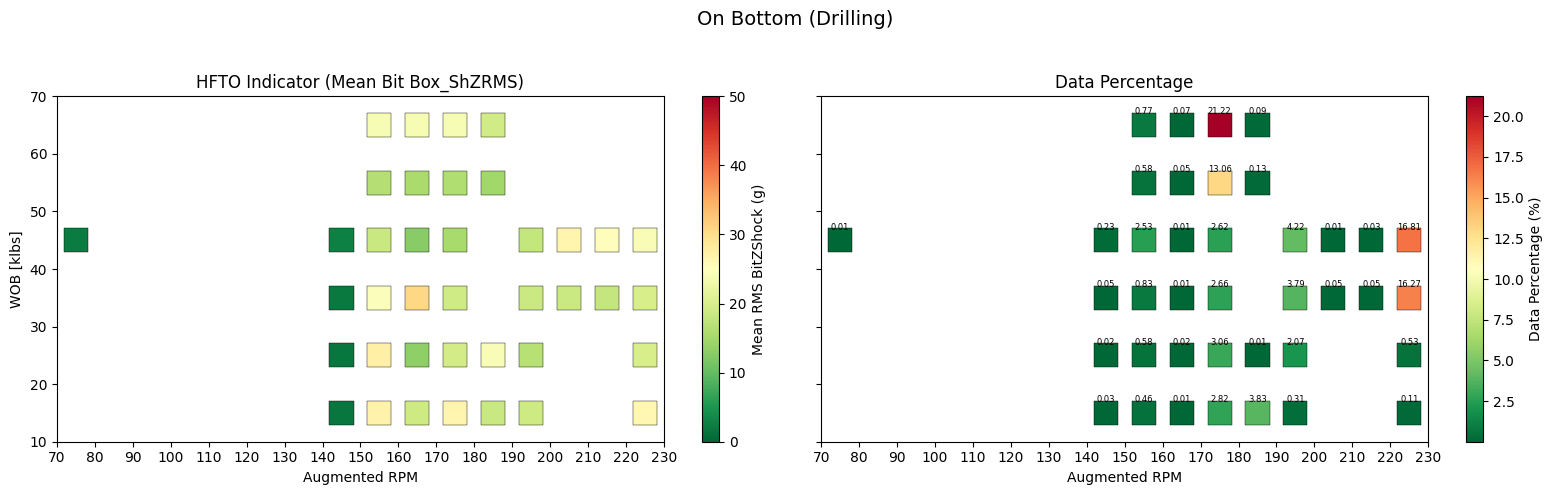

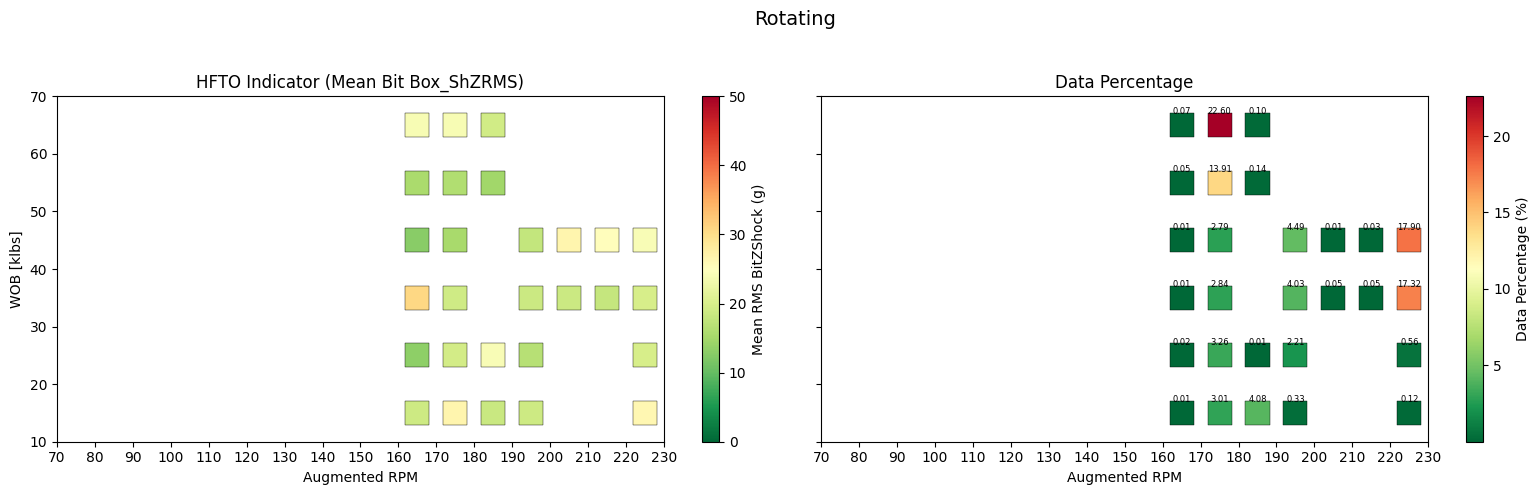

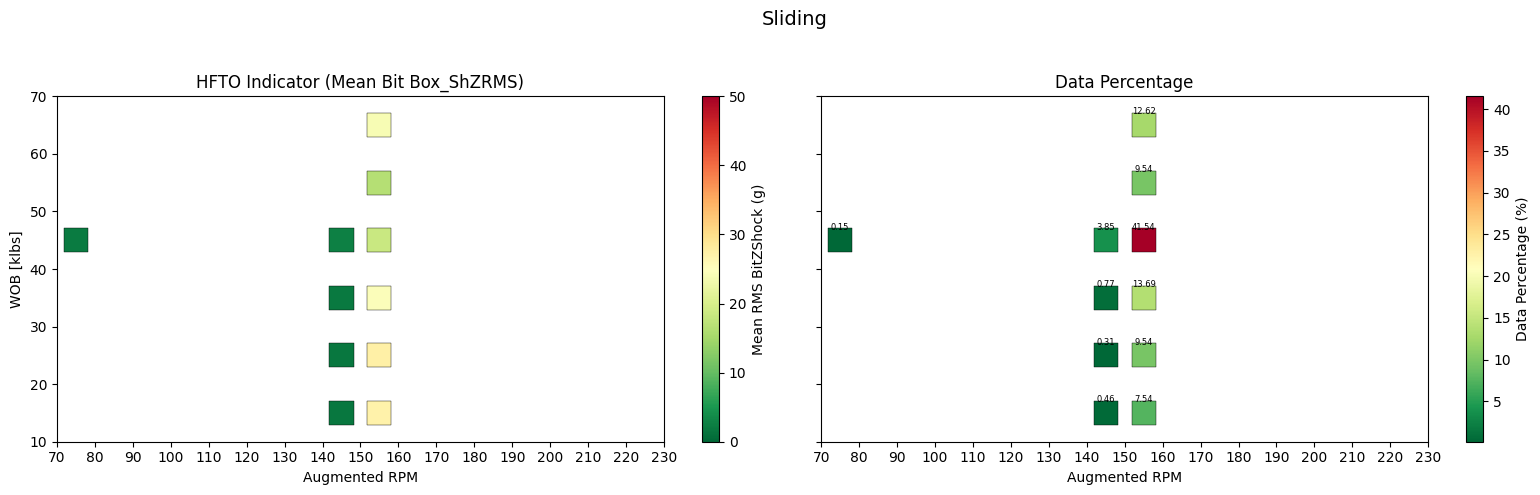

In [9]:
# ------------------------------------------------------------
# Operating states
# ------------------------------------------------------------
states = {
    "On Bottom (Drilling)": dataDrilling,
    "Rotating": dataRotating,
    "Sliding": dataSliding
}

selected_states = {
    "On Bottom (Drilling)": dataDrilling,
    "Rotating": dataRotating,
    "Sliding": dataSliding
}
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
nwob = 10
nrpm = 10

wob_col = "Surface_Weight on Bit(klbs)"
rpm_col = "Augmented RPM(RPM)"
hfto_col = lateralCol

# ------------------------------------------------------------
# GLOBAL mins/maxes (axis starts at GLOBAL MIN, not 0)
# ------------------------------------------------------------
minrpm_raw = min(df[rpm_col].min() for df in selected_states.values())
maxrpm_raw = max(df[rpm_col].max() for df in selected_states.values())

minwob_raw = min(df[wob_col].min() for df in selected_states.values())
maxwob_raw = max(df[wob_col].max() for df in selected_states.values())

# Bin-aligned bounds
minrpm = np.floor(minrpm_raw / nrpm) * nrpm
maxrpm = np.ceil(maxrpm_raw / nrpm) * nrpm

minwob = np.floor(minwob_raw / nwob) * nwob
maxwob = np.ceil(maxwob_raw / nwob) * nwob

rpm_edges = np.arange(minrpm, maxrpm + nrpm, nrpm)
wob_edges = np.arange(minwob, maxwob + nwob, nwob)

rpm_centers = rpm_edges[:-1] + nrpm / 2
wob_centers = wob_edges[:-1] + nwob / 2
RPM, WOB = np.meshgrid(rpm_centers, wob_centers)

# ------------------------------------------------------------
# GLOBAL colorbar limits (shared across all states)
# ------------------------------------------------------------
all_hfto_vals = []
all_pct_vals = []

for df in states.values():
    n_total = len(df)

    for wob_lo, wob_hi in zip(wob_edges[:-1], wob_edges[1:]):
        for rpm_lo, rpm_hi in zip(rpm_edges[:-1], rpm_edges[1:]):
            mask = (
                (df[wob_col] >= wob_lo) & (df[wob_col] < wob_hi) &
                (df[rpm_col] >= rpm_lo) & (df[rpm_col] < rpm_hi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                all_hfto_vals.append(vals.mean())
                all_pct_vals.append((len(vals) / n_total) * 100)

hfto_vmin = 0
hfto_vmax = 50

pct_vmin = 0
pct_vmax = max(all_pct_vals) if len(all_pct_vals) else np.nan



def plot_state(df, state_name):
    hfto = np.full((len(wob_centers), len(rpm_centers)), np.nan)
    pct  = np.full_like(hfto, np.nan)

    n_total = len(df)

    for yi, (wlo, whi) in enumerate(zip(wob_edges[:-1], wob_edges[1:])):
        for xi, (rlo, rhi) in enumerate(zip(rpm_edges[:-1], rpm_edges[1:])):
            mask = (
                (df[wob_col] >= wlo) & (df[wob_col] < whi) &
                (df[rpm_col] >= rlo) & (df[rpm_col] < rhi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                hfto[yi, xi] = vals.mean()
                pct[yi, xi] = (len(vals) / n_total) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)
    fig.suptitle(state_name, fontsize=14)

    sc1 = axes[0].scatter(
        RPM.flatten(), WOB.flatten(),
        c=hfto.flatten(),
        cmap="RdYlGn_r",
        vmin=hfto_vmin, vmax=hfto_vmax,
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    sc2 = axes[1].scatter(
        RPM.flatten(), WOB.flatten(),
        c=pct.flatten(),
        cmap="RdYlGn_r",
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    axes[0].set_title("HFTO Indicator (Mean Bit Box_ShZRMS)")
    axes[1].set_title("Data Percentage")

    axes[0].set_xlabel("Augmented RPM")
    axes[0].set_ylabel("WOB [klbs]")
    axes[1].set_xlabel("Augmented RPM")

    plt.colorbar(sc1, ax=axes[0], label="Mean RMS BitZShock (g)")
    plt.colorbar(sc2, ax=axes[1], label="Data Percentage (%)")

    # ---- LOCK TICKS TO BIN EDGES ----
    for ax in axes:
        ax.set_xlim(rpm_edges[0], rpm_edges[-1])
        ax.set_ylim(wob_edges[0], wob_edges[-1])
        ax.set_xticks(rpm_edges)
        ax.set_yticks(wob_edges)

    # Percentage labels
    for x, y, val in zip(RPM.flatten(), WOB.flatten(), pct.flatten()):
        if np.isfinite(val):
            axes[1].text(
                x,
                y + 0.15 * nwob,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=6
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    img_name = f"{input_csv}_{state_name}.png".replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f"output_images/{img_name}", bbox_inches='tight')
    plt.show()



# -----------------------------
# Run for each operating state
# -----------------------------
for name, df in states.items():
    plot_state(df, name)

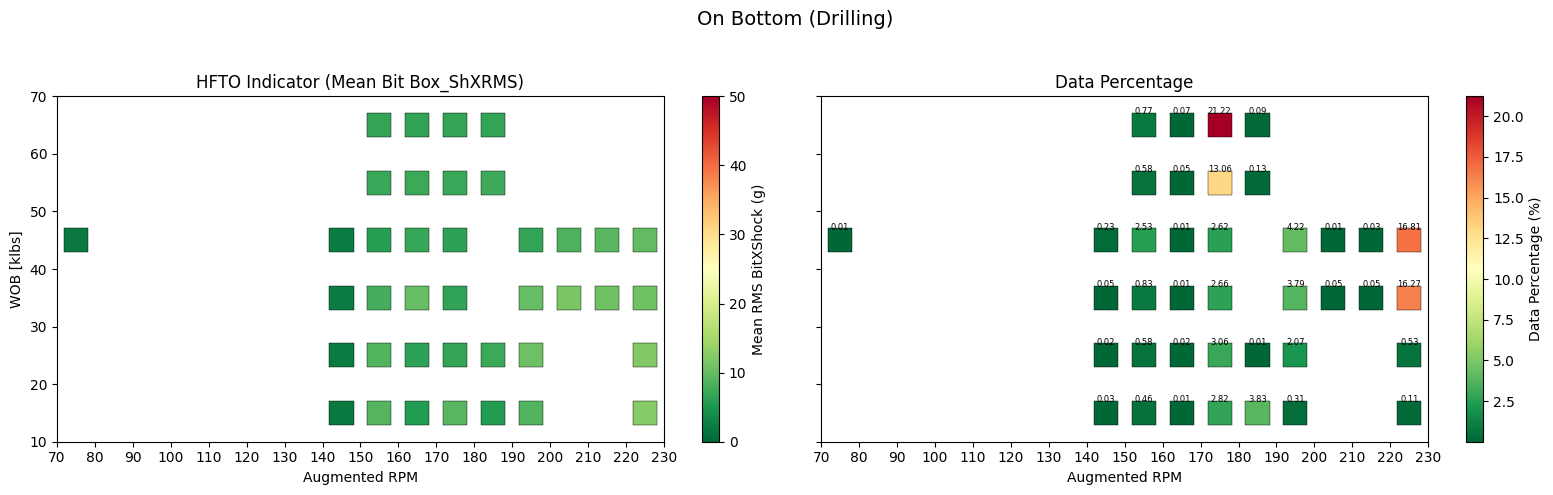

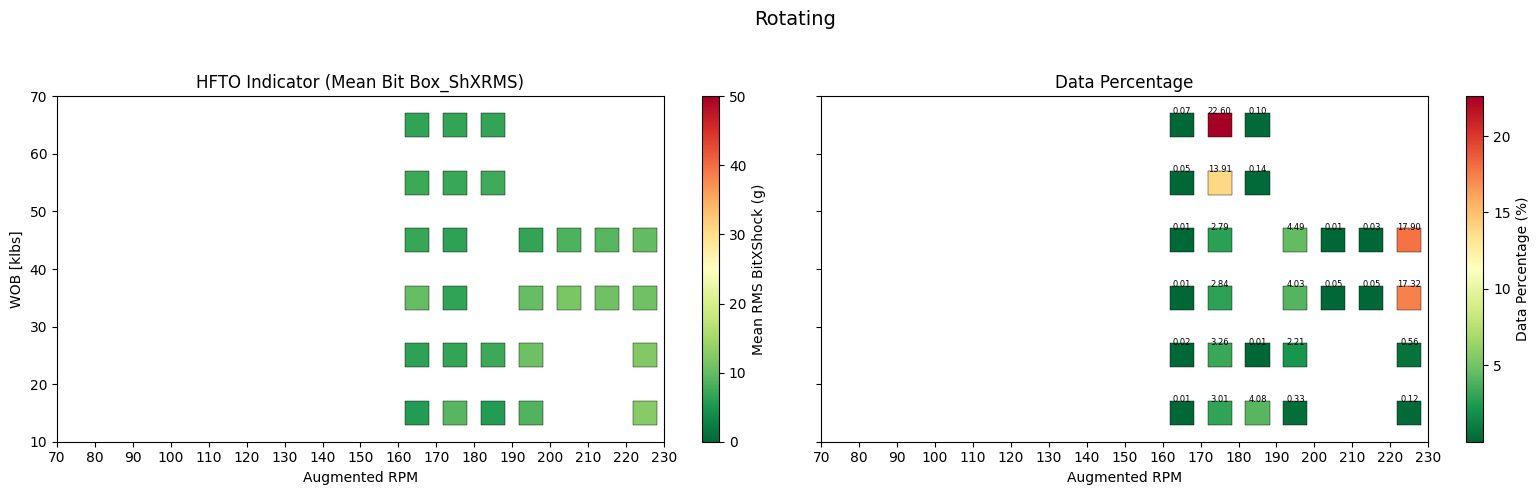

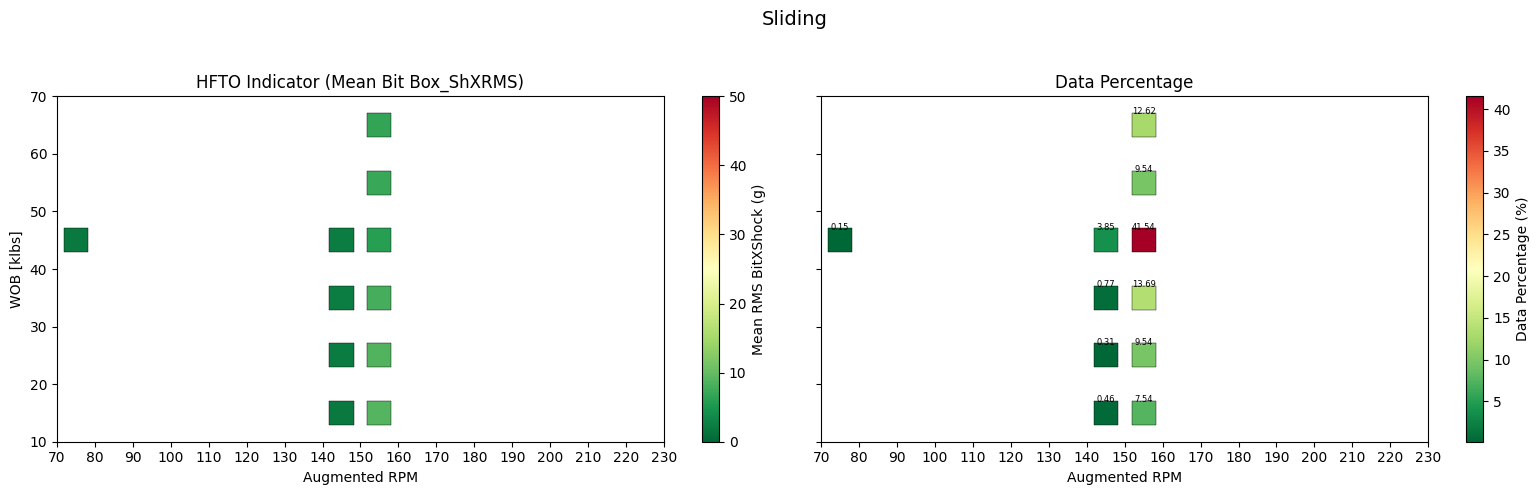

In [10]:
# ------------------------------------------------------------
# Operating states
# ------------------------------------------------------------
states = {
    "On Bottom (Drilling)": dataDrilling,
    "Rotating": dataRotating,
    "Sliding": dataSliding
}

selected_states = {
    "On Bottom (Drilling)": dataDrilling,
    "Rotating": dataRotating,
    "Sliding": dataSliding
}
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
nwob = 10
nrpm = 10

wob_col = "Surface_Weight on Bit(klbs)"
rpm_col = "Augmented RPM(RPM)"
hfto_col = axialCol

# ------------------------------------------------------------
# GLOBAL mins/maxes (axis starts at GLOBAL MIN, not 0)
# ------------------------------------------------------------
minrpm_raw = min(df[rpm_col].min() for df in selected_states.values())
maxrpm_raw = max(df[rpm_col].max() for df in selected_states.values())

minwob_raw = min(df[wob_col].min() for df in selected_states.values())
maxwob_raw = max(df[wob_col].max() for df in selected_states.values())

# Bin-aligned bounds
minrpm = np.floor(minrpm_raw / nrpm) * nrpm
maxrpm = np.ceil(maxrpm_raw / nrpm) * nrpm

minwob = np.floor(minwob_raw / nwob) * nwob
maxwob = np.ceil(maxwob_raw / nwob) * nwob

rpm_edges = np.arange(minrpm, maxrpm + nrpm, nrpm)
wob_edges = np.arange(minwob, maxwob + nwob, nwob)

rpm_centers = rpm_edges[:-1] + nrpm / 2
wob_centers = wob_edges[:-1] + nwob / 2
RPM, WOB = np.meshgrid(rpm_centers, wob_centers)

# ------------------------------------------------------------
# GLOBAL colorbar limits (shared across all states)
# ------------------------------------------------------------
all_hfto_vals = []
all_pct_vals = []

for df in states.values():
    n_total = len(df)

    for wob_lo, wob_hi in zip(wob_edges[:-1], wob_edges[1:]):
        for rpm_lo, rpm_hi in zip(rpm_edges[:-1], rpm_edges[1:]):
            mask = (
                (df[wob_col] >= wob_lo) & (df[wob_col] < wob_hi) &
                (df[rpm_col] >= rpm_lo) & (df[rpm_col] < rpm_hi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                all_hfto_vals.append(vals.mean())
                all_pct_vals.append((len(vals) / n_total) * 100)

hfto_vmin = 0
hfto_vmax = 50

pct_vmin = 0
pct_vmax = max(all_pct_vals) if len(all_pct_vals) else np.nan



def plot_state(df, state_name):
    hfto = np.full((len(wob_centers), len(rpm_centers)), np.nan)
    pct  = np.full_like(hfto, np.nan)

    n_total = len(df)

    for yi, (wlo, whi) in enumerate(zip(wob_edges[:-1], wob_edges[1:])):
        for xi, (rlo, rhi) in enumerate(zip(rpm_edges[:-1], rpm_edges[1:])):
            mask = (
                (df[wob_col] >= wlo) & (df[wob_col] < whi) &
                (df[rpm_col] >= rlo) & (df[rpm_col] < rhi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                hfto[yi, xi] = vals.mean()
                pct[yi, xi] = (len(vals) / n_total) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)
    fig.suptitle(state_name, fontsize=14)

    sc1 = axes[0].scatter(
        RPM.flatten(), WOB.flatten(),
        c=hfto.flatten(),
        cmap="RdYlGn_r",
        vmin=hfto_vmin, vmax=hfto_vmax,
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    sc2 = axes[1].scatter(
        RPM.flatten(), WOB.flatten(),
        c=pct.flatten(),
        cmap="RdYlGn_r",
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    axes[0].set_title("HFTO Indicator (Mean Bit Box_ShXRMS)")
    axes[1].set_title("Data Percentage")

    axes[0].set_xlabel("Augmented RPM")
    axes[0].set_ylabel("WOB [klbs]")
    axes[1].set_xlabel("Augmented RPM")

    plt.colorbar(sc1, ax=axes[0], label="Mean RMS BitXShock (g)")
    plt.colorbar(sc2, ax=axes[1], label="Data Percentage (%)")

    # ---- LOCK TICKS TO BIN EDGES ----
    for ax in axes:
        ax.set_xlim(rpm_edges[0], rpm_edges[-1])
        ax.set_ylim(wob_edges[0], wob_edges[-1])
        ax.set_xticks(rpm_edges)
        ax.set_yticks(wob_edges)

    # Percentage labels
    for x, y, val in zip(RPM.flatten(), WOB.flatten(), pct.flatten()):
        if np.isfinite(val):
            axes[1].text(
                x,
                y + 0.15 * nwob,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=6
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    img_name = f"{input_csv}_{state_name}.png".replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f"output_images/{img_name}", bbox_inches='tight')
    plt.show()



# -----------------------------
# Run for each operating state
# -----------------------------
for name, df in states.items():
    plot_state(df, name)

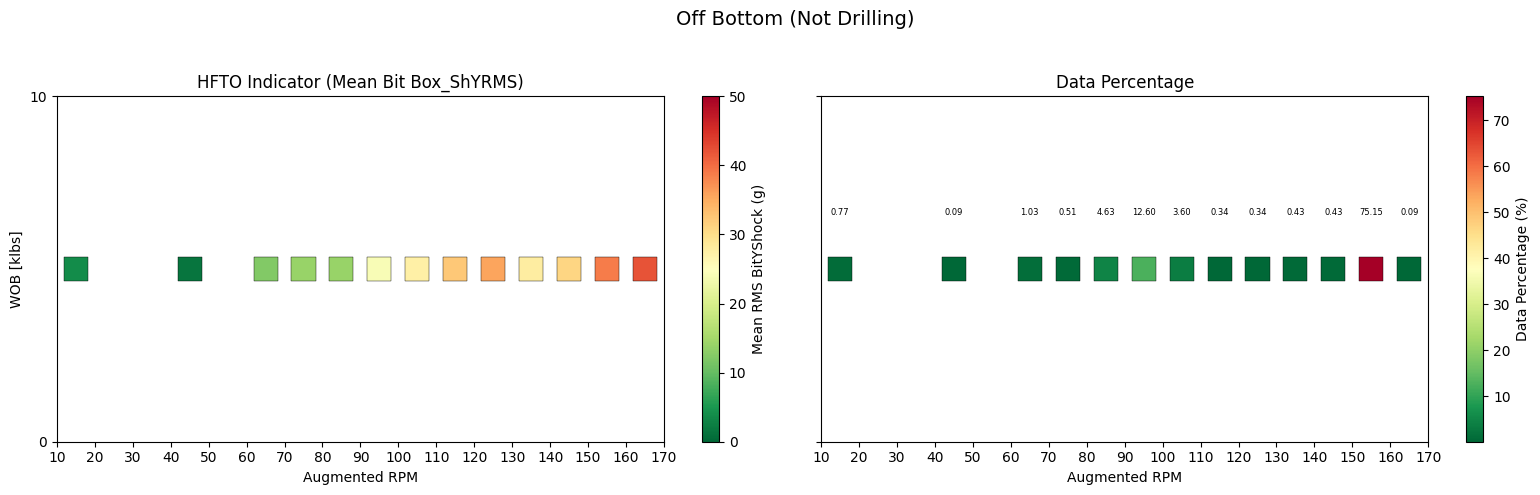

In [11]:
# ------------------------------------------------------------
# Operating states
# ------------------------------------------------------------
states = {
    "Off Bottom (Not Drilling)": dataNotDrilling
}
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
nwob = 10
nrpm = 10

wob_col = "Surface_Weight on Bit(klbs)"
rpm_col = "Augmented RPM(RPM)"
hfto_col = torsionalCol

# ------------------------------------------------------------
# GLOBAL mins/maxes (axis starts at GLOBAL MIN, not 0)
# ------------------------------------------------------------
minrpm_raw = min(df[rpm_col].min() for df in states.values())
maxrpm_raw = max(df[rpm_col].max() for df in states.values())

minwob_raw = min(df[wob_col].min() for df in states.values())
#maxwob_raw = max(df[wob_col].max() for df in states.values())
maxwob_raw = 10

# Bin-aligned bounds
minrpm = np.floor(minrpm_raw / nrpm) * nrpm
maxrpm = np.ceil(maxrpm_raw / nrpm) * nrpm

minwob = np.floor(minwob_raw / nwob) * nwob
maxwob = np.ceil(maxwob_raw / nwob) * nwob

rpm_edges = np.arange(minrpm, maxrpm + nrpm, nrpm)
wob_edges = np.arange(minwob, maxwob + nwob, nwob)

rpm_centers = rpm_edges[:-1] + nrpm / 2
wob_centers = wob_edges[:-1] + nwob / 2
RPM, WOB = np.meshgrid(rpm_centers, wob_centers)

# ------------------------------------------------------------
# GLOBAL colorbar limits (shared across all states)
# ------------------------------------------------------------
all_hfto_vals = []
all_pct_vals = []

for df in states.values():
    n_total = len(df)

    for wob_lo, wob_hi in zip(wob_edges[:-1], wob_edges[1:]):
        for rpm_lo, rpm_hi in zip(rpm_edges[:-1], rpm_edges[1:]):
            mask = (
                (df[wob_col] >= wob_lo) & (df[wob_col] < wob_hi) &
                (df[rpm_col] >= rpm_lo) & (df[rpm_col] < rpm_hi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                all_hfto_vals.append(vals.mean())
                all_pct_vals.append((len(vals) / n_total) * 100)

hfto_vmin = 0
hfto_vmax = 50

pct_vmin = 0
pct_vmax = max(all_pct_vals) if len(all_pct_vals) else np.nan



def plot_state(df, state_name):
    hfto = np.full((len(wob_centers), len(rpm_centers)), np.nan)
    pct  = np.full_like(hfto, np.nan)

    n_total = len(df)

    for yi, (wlo, whi) in enumerate(zip(wob_edges[:-1], wob_edges[1:])):
        for xi, (rlo, rhi) in enumerate(zip(rpm_edges[:-1], rpm_edges[1:])):
            mask = (
                (df[wob_col] >= wlo) & (df[wob_col] < whi) &
                (df[rpm_col] >= rlo) & (df[rpm_col] < rhi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                hfto[yi, xi] = vals.mean()
                pct[yi, xi] = (len(vals) / n_total) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)
    fig.suptitle(state_name, fontsize=14)

    sc1 = axes[0].scatter(
        RPM.flatten(), WOB.flatten(),
        c=hfto.flatten(),
        cmap="RdYlGn_r",
        vmin=hfto_vmin, vmax=hfto_vmax,
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    sc2 = axes[1].scatter(
        RPM.flatten(), WOB.flatten(),
        c=pct.flatten(),
        cmap="RdYlGn_r",
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    axes[0].set_title("HFTO Indicator (Mean Bit Box_ShYRMS)")
    axes[1].set_title("Data Percentage")

    axes[0].set_xlabel("Augmented RPM")
    axes[0].set_ylabel("WOB [klbs]")
    axes[1].set_xlabel("Augmented RPM")

    plt.colorbar(sc1, ax=axes[0], label="Mean RMS BitYShock (g)")
    plt.colorbar(sc2, ax=axes[1], label="Data Percentage (%)")

    # ---- LOCK TICKS TO BIN EDGES ----
    for ax in axes:
        ax.set_xlim(rpm_edges[0], rpm_edges[-1])
        ax.set_ylim(wob_edges[0], wob_edges[-1])
        ax.set_xticks(rpm_edges)
        ax.set_yticks(wob_edges)

    # Percentage labels
    for x, y, val in zip(RPM.flatten(), WOB.flatten(), pct.flatten()):
        if np.isfinite(val):
            axes[1].text(
                x,
                y + 0.15 * nwob,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=6
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    img_name = f"{input_csv}_{state_name}.png".replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f"output_images/{img_name}", bbox_inches='tight')
    plt.show()



# -----------------------------
# Run for each operating state
# -----------------------------
for name, df in states.items():
    plot_state(df, name)

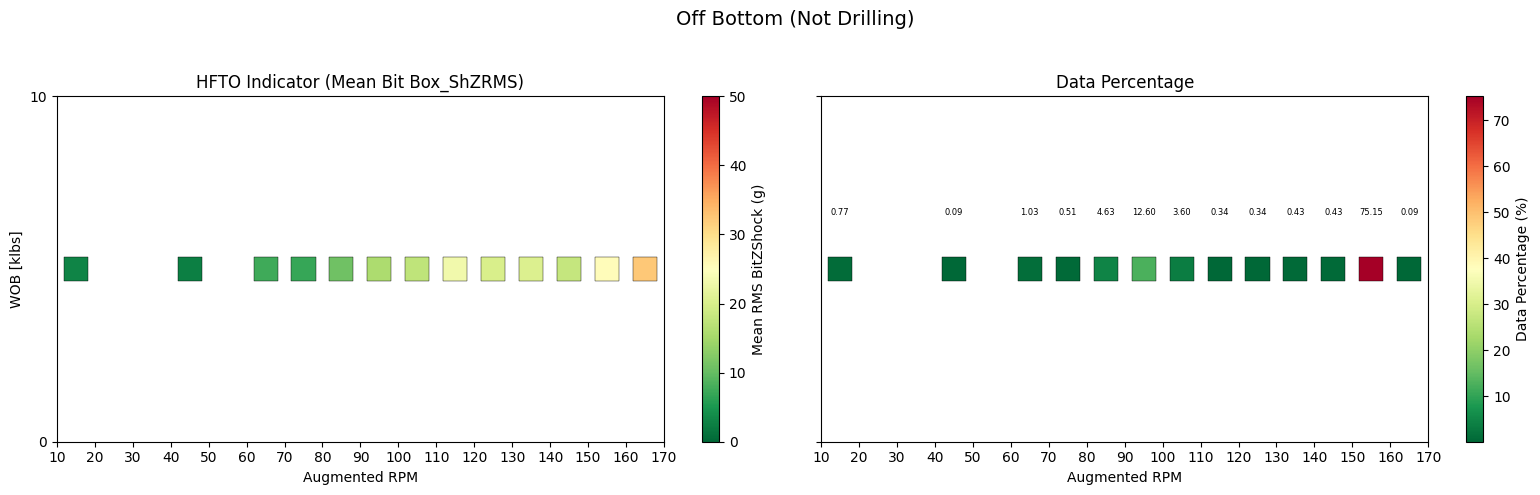

In [12]:
# ------------------------------------------------------------
# Operating states
# ------------------------------------------------------------
states = {
    "Off Bottom (Not Drilling)": dataNotDrilling
}
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
nwob = 10
nrpm = 10

wob_col = "Surface_Weight on Bit(klbs)"
rpm_col = "Augmented RPM(RPM)"
hfto_col = lateralCol

# ------------------------------------------------------------
# GLOBAL mins/maxes (axis starts at GLOBAL MIN, not 0)
# ------------------------------------------------------------
minrpm_raw = min(df[rpm_col].min() for df in states.values())
maxrpm_raw = max(df[rpm_col].max() for df in states.values())

minwob_raw = min(df[wob_col].min() for df in states.values())
#maxwob_raw = max(df[wob_col].max() for df in states.values())
maxwob_raw = 10

# Bin-aligned bounds
minrpm = np.floor(minrpm_raw / nrpm) * nrpm
maxrpm = np.ceil(maxrpm_raw / nrpm) * nrpm

minwob = np.floor(minwob_raw / nwob) * nwob
maxwob = np.ceil(maxwob_raw / nwob) * nwob

rpm_edges = np.arange(minrpm, maxrpm + nrpm, nrpm)
wob_edges = np.arange(minwob, maxwob + nwob, nwob)

rpm_centers = rpm_edges[:-1] + nrpm / 2
wob_centers = wob_edges[:-1] + nwob / 2
RPM, WOB = np.meshgrid(rpm_centers, wob_centers)

# ------------------------------------------------------------
# GLOBAL colorbar limits (shared across all states)
# ------------------------------------------------------------
all_hfto_vals = []
all_pct_vals = []

for df in states.values():
    n_total = len(df)

    for wob_lo, wob_hi in zip(wob_edges[:-1], wob_edges[1:]):
        for rpm_lo, rpm_hi in zip(rpm_edges[:-1], rpm_edges[1:]):
            mask = (
                (df[wob_col] >= wob_lo) & (df[wob_col] < wob_hi) &
                (df[rpm_col] >= rpm_lo) & (df[rpm_col] < rpm_hi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                all_hfto_vals.append(vals.mean())
                all_pct_vals.append((len(vals) / n_total) * 100)

hfto_vmin = 0
hfto_vmax = 50

pct_vmin = 0
pct_vmax = max(all_pct_vals) if len(all_pct_vals) else np.nan



def plot_state(df, state_name):
    hfto = np.full((len(wob_centers), len(rpm_centers)), np.nan)
    pct  = np.full_like(hfto, np.nan)

    n_total = len(df)

    for yi, (wlo, whi) in enumerate(zip(wob_edges[:-1], wob_edges[1:])):
        for xi, (rlo, rhi) in enumerate(zip(rpm_edges[:-1], rpm_edges[1:])):
            mask = (
                (df[wob_col] >= wlo) & (df[wob_col] < whi) &
                (df[rpm_col] >= rlo) & (df[rpm_col] < rhi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                hfto[yi, xi] = vals.mean()
                pct[yi, xi] = (len(vals) / n_total) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)
    fig.suptitle(state_name, fontsize=14)

    sc1 = axes[0].scatter(
        RPM.flatten(), WOB.flatten(),
        c=hfto.flatten(),
        cmap="RdYlGn_r",
        vmin=hfto_vmin, vmax=hfto_vmax,
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    sc2 = axes[1].scatter(
        RPM.flatten(), WOB.flatten(),
        c=pct.flatten(),
        cmap="RdYlGn_r",
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    axes[0].set_title("HFTO Indicator (Mean Bit Box_ShZRMS)")
    axes[1].set_title("Data Percentage")

    axes[0].set_xlabel("Augmented RPM")
    axes[0].set_ylabel("WOB [klbs]")
    axes[1].set_xlabel("Augmented RPM")

    plt.colorbar(sc1, ax=axes[0], label="Mean RMS BitZShock (g)")
    plt.colorbar(sc2, ax=axes[1], label="Data Percentage (%)")

    # ---- LOCK TICKS TO BIN EDGES ----
    for ax in axes:
        ax.set_xlim(rpm_edges[0], rpm_edges[-1])
        ax.set_ylim(wob_edges[0], wob_edges[-1])
        ax.set_xticks(rpm_edges)
        ax.set_yticks(wob_edges)

    # Percentage labels
    for x, y, val in zip(RPM.flatten(), WOB.flatten(), pct.flatten()):
        if np.isfinite(val):
            axes[1].text(
                x,
                y + 0.15 * nwob,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=6
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    img_name = f"{input_csv}_{state_name}.png".replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f"output_images/{img_name}", bbox_inches='tight')
    plt.show()



# -----------------------------
# Run for each operating state
# -----------------------------
for name, df in states.items():
    plot_state(df, name)

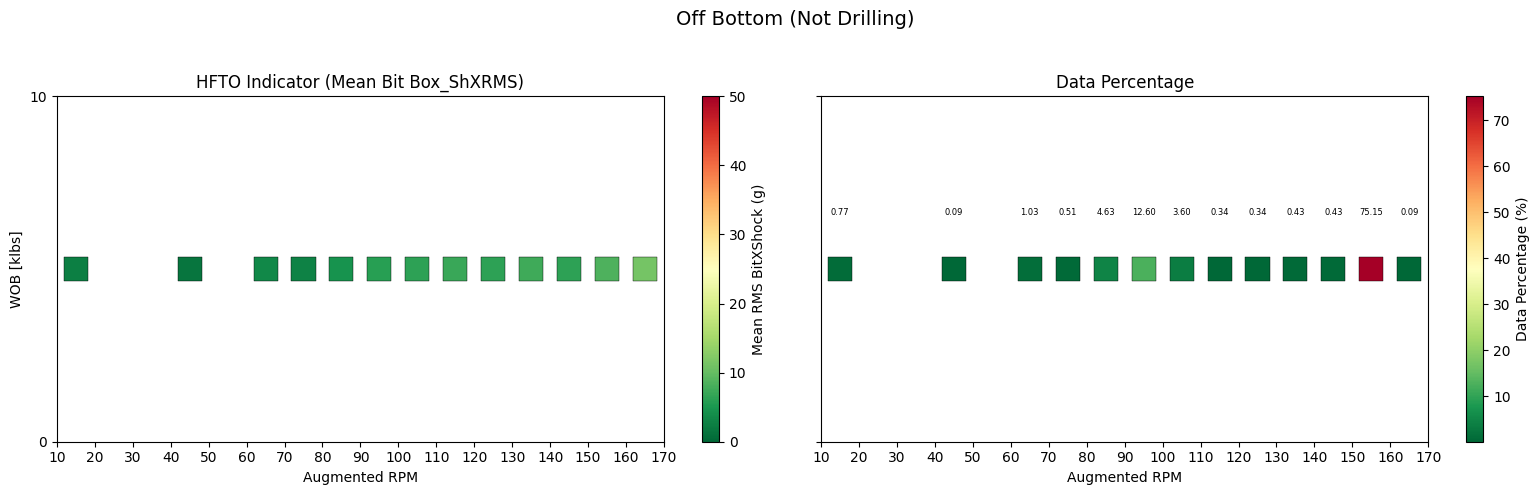

In [13]:
# ------------------------------------------------------------
# Operating states
# ------------------------------------------------------------
states = {
    "Off Bottom (Not Drilling)": dataNotDrilling
}
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
nwob = 10
nrpm = 10

wob_col = "Surface_Weight on Bit(klbs)"
rpm_col = "Augmented RPM(RPM)"
hfto_col = axialCol

# ------------------------------------------------------------
# GLOBAL mins/maxes (axis starts at GLOBAL MIN, not 0)
# ------------------------------------------------------------
minrpm_raw = min(df[rpm_col].min() for df in states.values())
maxrpm_raw = max(df[rpm_col].max() for df in states.values())

minwob_raw = min(df[wob_col].min() for df in states.values())
#maxwob_raw = max(df[wob_col].max() for df in states.values())
maxwob_raw = 10

# Bin-aligned bounds
minrpm = np.floor(minrpm_raw / nrpm) * nrpm
maxrpm = np.ceil(maxrpm_raw / nrpm) * nrpm

minwob = np.floor(minwob_raw / nwob) * nwob
maxwob = np.ceil(maxwob_raw / nwob) * nwob

rpm_edges = np.arange(minrpm, maxrpm + nrpm, nrpm)
wob_edges = np.arange(minwob, maxwob + nwob, nwob)

rpm_centers = rpm_edges[:-1] + nrpm / 2
wob_centers = wob_edges[:-1] + nwob / 2
RPM, WOB = np.meshgrid(rpm_centers, wob_centers)

# ------------------------------------------------------------
# GLOBAL colorbar limits (shared across all states)
# ------------------------------------------------------------
all_hfto_vals = []
all_pct_vals = []

for df in states.values():
    n_total = len(df)

    for wob_lo, wob_hi in zip(wob_edges[:-1], wob_edges[1:]):
        for rpm_lo, rpm_hi in zip(rpm_edges[:-1], rpm_edges[1:]):
            mask = (
                (df[wob_col] >= wob_lo) & (df[wob_col] < wob_hi) &
                (df[rpm_col] >= rpm_lo) & (df[rpm_col] < rpm_hi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                all_hfto_vals.append(vals.mean())
                all_pct_vals.append((len(vals) / n_total) * 100)

hfto_vmin = 0
hfto_vmax = 50

pct_vmin = 0
pct_vmax = max(all_pct_vals) if len(all_pct_vals) else np.nan



def plot_state(df, state_name):
    hfto = np.full((len(wob_centers), len(rpm_centers)), np.nan)
    pct  = np.full_like(hfto, np.nan)

    n_total = len(df)

    for yi, (wlo, whi) in enumerate(zip(wob_edges[:-1], wob_edges[1:])):
        for xi, (rlo, rhi) in enumerate(zip(rpm_edges[:-1], rpm_edges[1:])):
            mask = (
                (df[wob_col] >= wlo) & (df[wob_col] < whi) &
                (df[rpm_col] >= rlo) & (df[rpm_col] < rhi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                hfto[yi, xi] = vals.mean()
                pct[yi, xi] = (len(vals) / n_total) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)
    fig.suptitle(state_name, fontsize=14)

    sc1 = axes[0].scatter(
        RPM.flatten(), WOB.flatten(),
        c=hfto.flatten(),
        cmap="RdYlGn_r",
        vmin=hfto_vmin, vmax=hfto_vmax,
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    sc2 = axes[1].scatter(
        RPM.flatten(), WOB.flatten(),
        c=pct.flatten(),
        cmap="RdYlGn_r",
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    axes[0].set_title("HFTO Indicator (Mean Bit Box_ShXRMS)")
    axes[1].set_title("Data Percentage")

    axes[0].set_xlabel("Augmented RPM")
    axes[0].set_ylabel("WOB [klbs]")
    axes[1].set_xlabel("Augmented RPM")

    plt.colorbar(sc1, ax=axes[0], label="Mean RMS BitXShock (g)")
    plt.colorbar(sc2, ax=axes[1], label="Data Percentage (%)")

    # ---- LOCK TICKS TO BIN EDGES ----
    for ax in axes:
        ax.set_xlim(rpm_edges[0], rpm_edges[-1])
        ax.set_ylim(wob_edges[0], wob_edges[-1])
        ax.set_xticks(rpm_edges)
        ax.set_yticks(wob_edges)

    # Percentage labels
    for x, y, val in zip(RPM.flatten(), WOB.flatten(), pct.flatten()):
        if np.isfinite(val):
            axes[1].text(
                x,
                y + 0.15 * nwob,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=6
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    img_name = f"{input_csv}_{state_name}.png".replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f"output_images/{img_name}", bbox_inches='tight')
    plt.show()



# -----------------------------
# Run for each operating state
# -----------------------------
for name, df in states.items():
    plot_state(df, name)